In [95]:
import yfinance as yf
import pandas as pd
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [99]:
# ticker_symbol = "RELIANCE.NS"
ticker_symbol = "BHARTIARTL.NS"
# ticker_symbol = "AAPL"

if os.path.exists("stock_data.csv"):
    df = pd.read_csv("stock_data.csv", index_col=0, parse_dates=True)
else:
    print("Downloading data")
    df = yf.download(ticker_symbol, period="5y")
    df.columns = df.columns.get_level_values(0)
    df.to_csv("stock_data.csv")

[*********************100%***********************]  1 of 1 completed


In [100]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-03-15,501.595184,506.343946,495.407376,506.343946,10875944
2021-03-16,507.782898,512.051987,502.698348,502.698348,13252045
2021-03-17,501.643158,509.413897,497.901702,507.303303,8482758
2021-03-18,505.768341,510.565064,494.400060,508.310586,12465338
2021-03-19,508.406494,513.011372,504.137405,506.535766,49597558


In [101]:
df = df.sort_index()
df['SMA'] = df['Close'].rolling(window=50).mean()
df.head()

Price,Close,High,Low,Open,Volume,SMA
Date,,,,,,
2021-03-15,501.595184,506.343946,495.407376,506.343946,10875944,NaN
2021-03-16,507.782898,512.051987,502.698348,502.698348,13252045,NaN
2021-03-17,501.643158,509.413897,497.901702,507.303303,8482758,NaN
2021-03-18,505.768341,510.565064,494.400060,508.310586,12465338,NaN
2021-03-19,508.406494,513.011372,504.137405,506.535766,49597558,NaN


In [102]:
df.dropna(inplace=True)

df['Error'] = df['Close'] - df['SMA']
df['Percentage'] = df['Error'].abs() / df['Close']
result = df['Percentage'].mean() * 100
result, df.head(5)

(np.float64(4.231044548685956),
 Price            Close        High         Low        Open    Volume  \
 Date                                                                   
 2021-05-28  502.314667  507.015467  499.244758  501.019534  10248988   
 2021-05-31  513.155273  514.210540  503.753614  504.137364  12803471   
 2021-06-01  511.236542  516.512996  508.742258  515.601613   8435896   
 2021-06-02  507.974792  512.867497  506.535776  508.358542  10567595   
 2021-06-03  510.421204  511.716277  507.015477  508.454493   6290021   
 
 Price              SMA      Error  Percentage  
 Date                                           
 2021-05-28  513.735709 -11.421042    0.022737  
 2021-05-31  513.966910  -0.811637    0.001582  
 2021-06-01  514.035983  -2.799442    0.005476  
 2021-06-02  514.162616  -6.187823    0.012181  
 2021-06-03  514.255673  -3.834470    0.007512  )

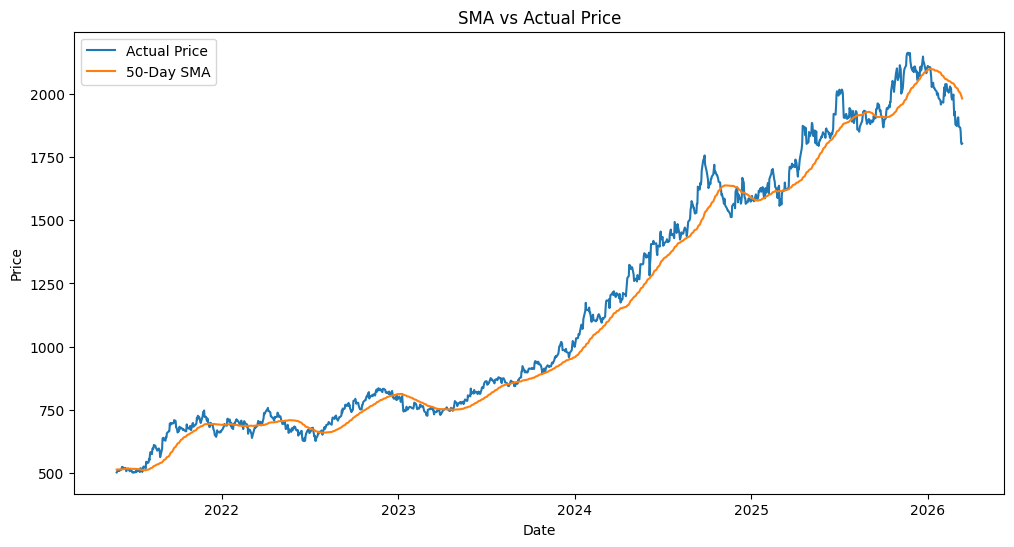

In [103]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Price')
plt.plot(df.index, df['SMA'], label='50-Day SMA')
plt.title('SMA vs Actual Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

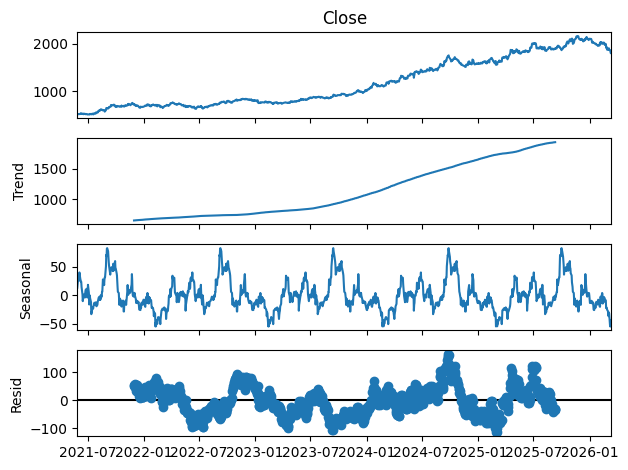

In [104]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=252)
decomposition.plot()
plt.show()

In [105]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA', 'Error', 'Percentage'], dtype='object', name='Price')

In [106]:
adf_res = adfuller(df['Close'])
adf_res[1]

np.float64(0.8668179993373395)

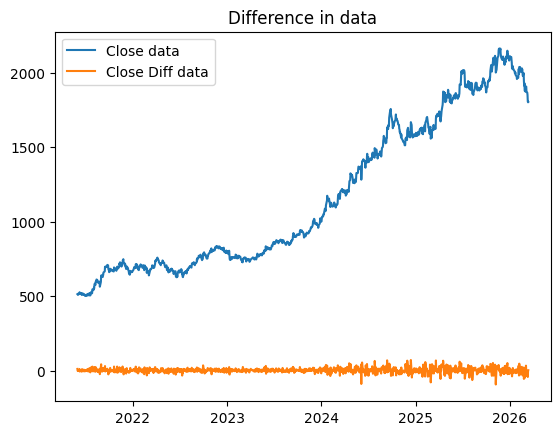

(None, np.float64(4.916067188485135e-18))

In [107]:
df["Close_Diff"] = df["Close"].diff()
df.dropna(inplace=True)
adf_res_new = adfuller(df['Close_Diff'])
# adf_res_new[1]
plt.plot(df.index, df["Close"], label="Close data")
plt.plot(df.index, df["Close_Diff"], label="Close Diff data")
plt.title("Difference in data")
plt.legend()
plt.show(), adf_res_new[1]

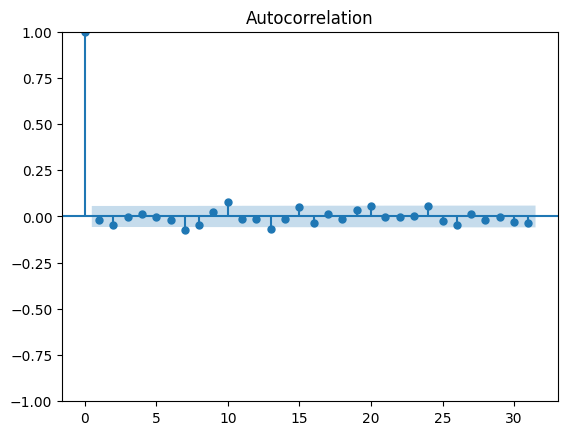

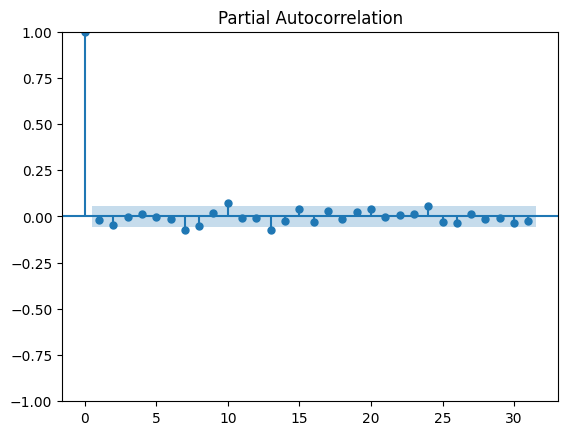

In [108]:
plot_acf(df['Close_Diff'])
plot_pacf(df['Close_Diff'])
plt.show()

In [109]:
model = ARIMA(df['Close'], order=(1, 3, 3))
fitted_model = model.fit()
fitted_model.summary()

C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starti

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1187
Model:                 ARIMA(1, 3, 3)   Log Likelihood               -5018.773
Date:                Sat, 14 Mar 2026   AIC                          10047.546
Time:                        22:38:07   BIC                          10072.930
Sample:                             0   HQIC                         10057.114
                               - 1187                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9943      0.005   -190.610      0.000      -1.005      -0.984
ma.L1         -0.9995      0.146     -6.869      0.000      -1.285      -0.714
ma.L2         -0.9999      0.291     -3.437      0.001      -1.570      -0.430
ma.L3          0.9995      0.148      6.770      0.000       0.710       1.289
sigma2       275.8389     39.931      6.908      0.000     197.576     354.102
===================================================================================
Ljung-Box (L1) (Q):                   0.72   Jarque-Bera (JB):               679.11
Prob(Q):                              0.40   Prob(JB):                         0.00
Heteroskedasticity (H):               4.61   Skew:                            -0.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [110]:
future_prices = fitted_model.forecast(steps=5)
print(future_prices)

1187    1803.566072
1188    1801.376244
1189    1801.468874
1190    1799.232030
1191    1799.251393
Name: predicted_mean, dtype: float64


C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [115]:
new_df = df[:-108]
model1 = ARIMA(new_df['Close'], order=(0, 1, 0))
fitted_model1 = model1.fit()
# print(fitted_model1.summary())
future_prices_new = fitted_model1.forecast(steps=7)
future_prices_new.index = df.index[-107:-100]
print(future_prices_new)


Date
2025-10-09    1929.0
2025-10-10    1929.0
2025-10-13    1929.0
2025-10-14    1929.0
2025-10-15    1929.0
2025-10-16    1929.0
2025-10-17    1929.0
Name: predicted_mean, dtype: float64


C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given wit

C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning

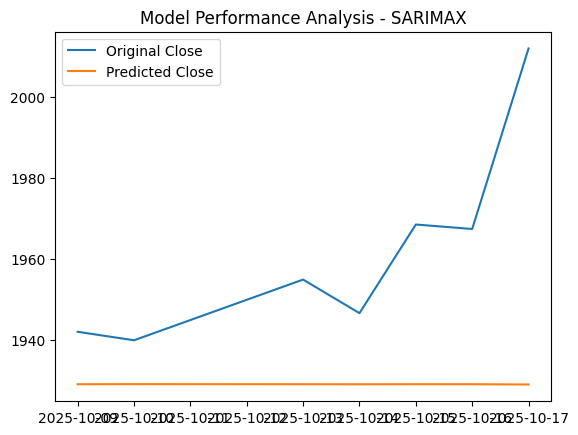

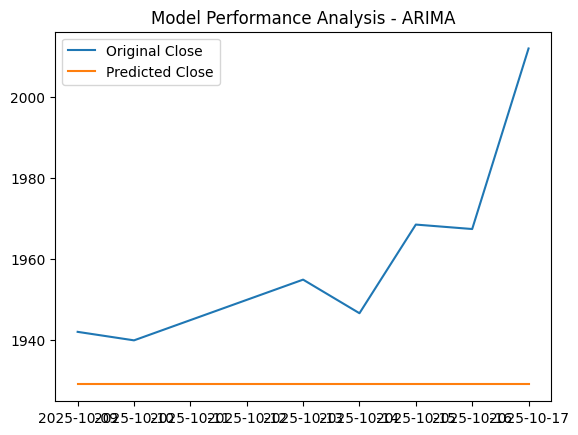

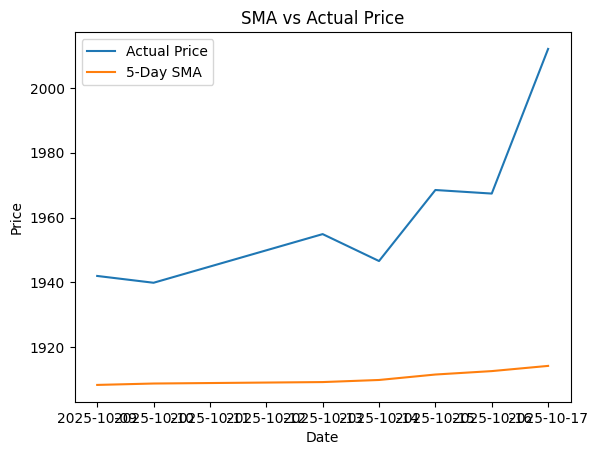

In [116]:
model_sarimax = SARIMAX(new_df['Close'], exog=new_df['Volume'], order=(0, 1, 0)).fit()
future_prices_sarimax = model_sarimax.forecast(steps=7, exog=df[-107:-100]['Volume'])
future_prices_sarimax.index = df.index[-107:-100]
plt.plot(df.index[-107:-100], df['Close'][-107:-100], label='Original Close')
plt.plot(df.index[-107:-100], future_prices_sarimax, label="Predicted Close")
plt.title("Model Performance Analysis - SARIMAX")
plt.legend()
plt.show()

plt.plot(df.index[-107:-100], df['Close'][-107:-100], label='Original Close')
plt.plot(df.index[-107:-100], future_prices_new, label="Predicted Close")
plt.title("Model Performance Analysis - ARIMA")
plt.legend()
plt.show()

plt.plot(df.index[-107:-100], df['Close'][-107:-100], label='Actual Price')
plt.plot(df.index[-107:-100], df['SMA'][-107:-100], label='5-Day SMA')
plt.title('SMA vs Actual Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()